In [40]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from models import PINN, FNN, device, dtype
from sklearn.model_selection import train_test_split

### Data Genration and Second Derivative Definition

In [41]:
def generate_data(n_samples, a=-1, b=1):
    x = np.random.uniform(a, b, n_samples)  # Uniform in [-1, 1]
    # Target function
    y = -x ** 2 + 1
    return torch.tensor(x, dtype=dtype, device=device).unsqueeze(1), torch.tensor(y, dtype=dtype, device=device).unsqueeze(1)

# Model the target physics
def target_physics(x):
    return -2 * torch.ones_like(x)

# Generate data with the function defined above
x_gen, y_gen = generate_data(10000, a=-1, b=0.2)
x_train, x_val, y_train, y_val = train_test_split(x_gen, y_gen, test_size=0.2, random_state=42)

In [42]:
model_1 = PINN([1, 256, 1]).to(device)
train_loss_1, val_loss_1 = model_1.train_model(
    x_train, y_train, 
    epochs=5000, 
    lr=1e-3, 
    track_loss=True,                    # Enable loss tracking for visualization
    x_val=x_val, 
    y_val=y_val, 
    target_physics=target_physics,      # Definition of the second order derivative
    lambda_phy= 0.8,                    # Weight for the physics loss
    lambda_data= 0.2                    # Weight for the data loss
    )

model_2 = FNN([1, 256, 1], activation=torch.nn.Tanh).to(device)
train_loss_2, val_loss_2 = model_2.train_model(
    x_train, y_train, 
    epochs=5000, 
    lr=1e-3, 
    track_loss=True,                    # Enable loss tracking for visualization
    x_val=x_val, 
    y_val=y_val,
)

Training Epoch: 100%|██████████| 5000/5000 [00:31<00:00, 159.15it/s]


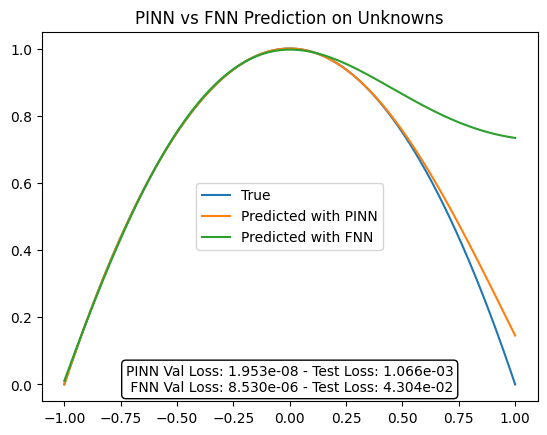

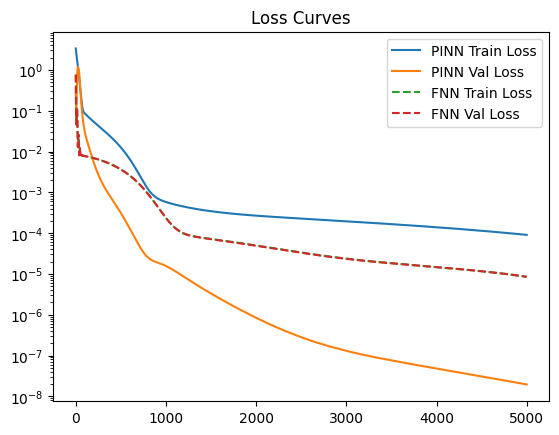

In [43]:

x_test = torch.linspace(-1, 1, 1000).unsqueeze(1).to(device)
y_true = -x_test ** 2 + 1

y_pred_1 = model_1.predict(x_test).cpu().numpy().flatten()
y_pred_2 = model_2.predict(x_test).cpu().numpy().flatten()
test_loss_1 = np.mean((y_pred_1 - y_true.cpu().numpy().flatten()) ** 2)
test_loss_2 = np.mean((y_pred_2 - y_true.cpu().numpy().flatten()) ** 2)

plt.plot(x_test, y_true, label='True')
plt.plot(x_test, y_pred_1, label='Predicted with PINN')
plt.plot(x_test, y_pred_2, label='Predicted with FNN')
plt.title('PINN vs FNN Prediction on Unknowns')
plt.legend()
textstr = f'PINN Val Loss: {val_loss_1[-1]:.3e} - Test Loss: {test_loss_1:.3e}\n FNN Val Loss: {val_loss_2[-1]:.3e} - Test Loss: {test_loss_2:.3e}'
props = dict(boxstyle='round', facecolor='white', edgecolor='black')
plt.text(0.5, 0.1, textstr, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', horizontalalignment='center', bbox=props)
plt.show()

plt.figure()
plt.semilogy(train_loss_1, label='PINN Train Loss')
plt.semilogy(val_loss_1, label='PINN Val Loss')
plt.semilogy(train_loss_2, '--', label='FNN Train Loss')
plt.semilogy(val_loss_2, '--', label='FNN Val Loss')
plt.title('Loss Curves')
plt.legend()
plt.show()